# Homework 7: Linear models.

*Instructions:*
Please answer the following questions and submit your work
by editing this jupyter notebook and submitting it on Canvas.
Questions may involve math, programming, or neither,
but you should make sure to *explain your work*:
i.e., you should usually have a cell with at least a few sentences
explaining what you are doing.

Also, please be sure to always specify units of any quantities that have units,
and label axes of plots (again, with units when appropriate).

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.stats import poisson
from scipy.optimize import minimize
rng = np.random.default_rng(123)

# 1. All models are wrong

Suppose that you have data that has *heteroskedasticity*:
the standard deviation is not constant:
$$\begin{aligned}
    X_I &\sim \text{Poisson}(\text{mean}=2) \\
    Y_i &\sim \text{Normal}(\text{mean}= a X_i + b, \text{sd}=a X_i / 4) .
\end{aligned}$$
Because of the heteroskedasticity, this does not satisfy the usual assumptions of a linear model.
However, you'd like to use the standard (least squares) linear model to analyze the data;
how well does this work in practice? To answer this question

*(a)* Write a function that simulates a dataset from the model above.
The sample size, $n$, should be an argument to the function,
as well as $a$ and $b$.


In [33]:
def simulate_heteroskedastic_data(n, a, b):
    """
    Simulate a heteroskedastic dataset:
    X ~ Poisson(mean=2)
    Y ~ Normal(mean=aX+b, sd=aX/4)
    sd is clipped to avoid zero when X=0.
    """
    X = rng.poisson(lam=2, size=n)
    std_dev = np.where(X == 0, 1e-9, (a * X) / 4)
    Y = rng.normal(loc=(a * X + b), scale=std_dev)
    return pd.DataFrame({'X': X, 'Y': Y})

# Quick check
df_test = simulate_heteroskedastic_data(n=5, a=5, b=1)
print(df_test)

   X          Y
0  1   7.250337
1  1   6.170401
2  2  14.830083
3  3  13.525115
4  2  10.220513


*(b)* Simulate one data set with $n=100$, $a=5$, and $b=1$,
and fit a (standard, least squares) linear model to the data.
You can use either the formula from class or scikit-learn.
Plot or otherwise depict the data and predicted values from the model
(e.g., the line on top of the scatter).


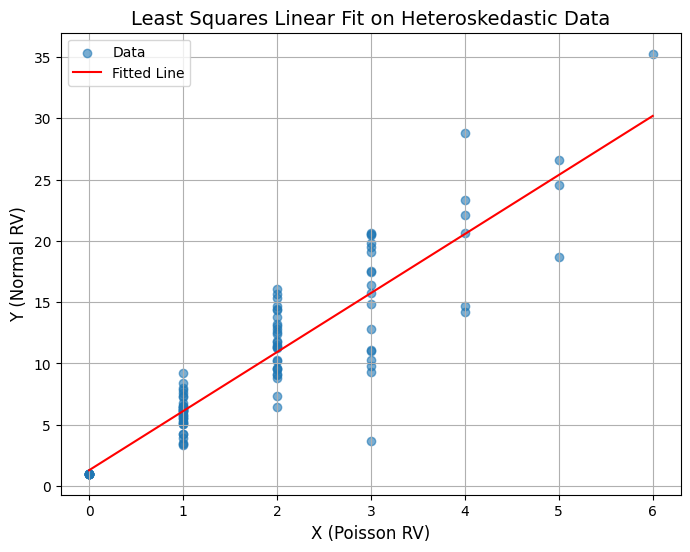

True values:        a=5, b=1
sklearn:            slope=4.8172, intercept=1.2851
Normal equations:   a=4.8172, b=1.2851


In [34]:
n, a, b = 100, 5, 1
df = simulate_heteroskedastic_data(n=n, a=a, b=b)

X = df[['X']].values
Y = df['Y'].values

model = LinearRegression()
model.fit(X, Y)

Xmat = np.column_stack([X, np.ones(n)])
beta = np.linalg.lstsq(Xmat, Y, rcond=None)[0]
a_hat, b_hat = beta

# Plot
X_range = np.linspace(df['X'].min(), df['X'].max(), 100).reshape(-1, 1)
Y_pred = model.predict(X_range)

plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], alpha=0.6, label="Data")
plt.plot(X_range, Y_pred, color='red', label="Fitted Line")
plt.xlabel("X (Poisson RV)", fontsize=12)
plt.ylabel("Y (Normal RV)", fontsize=12)
plt.title("Least Squares Linear Fit on Heteroskedastic Data", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Report both methods — should match
print(f"True values:        a={a}, b={b}")
print(f"sklearn:            slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
print(f"Normal equations:   a={a_hat:.4f}, b={b_hat:.4f}")

*(c)* Do the same thing as in (b) for at least 100 additional simulated datasets,
then report across these datasets how well the values of $a$ and $b$ were estimated
(i.e., how close the estimates were to the true values of $a=5$ and $b=1$).
Summarize the results.

True a=5:  mean estimate=5.0100, std=0.3278
True b=1:  mean estimate=0.9825, std=0.4699


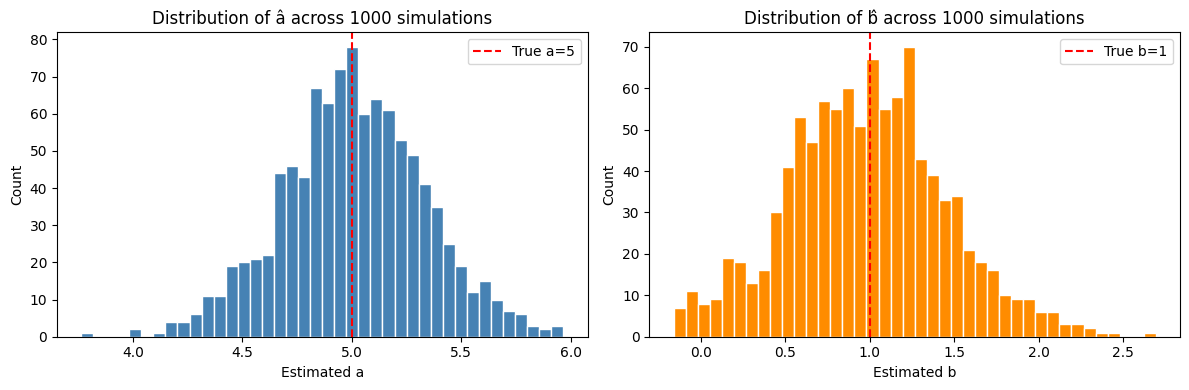

In [35]:
n_sims = 1000
a_true, b_true = 5, 1
n = 100

slopes = []
intercepts = []

for i in range(n_sims):
    df_sim = simulate_heteroskedastic_data(n=n, a=a_true, b=b_true)
    model_sim = LinearRegression()
    X_sim = df_sim[['X']].values
    Y_sim = df_sim['Y'].values
    model_sim.fit(X_sim, Y_sim)
    slopes.append(model_sim.coef_[0])
    intercepts.append(model_sim.intercept_)

slopes = np.array(slopes)
intercepts = np.array(intercepts)

print(f"True a=5:  mean estimate={slopes.mean():.4f}, std={slopes.std():.4f}")
print(f"True b=1:  mean estimate={intercepts.mean():.4f}, std={intercepts.std():.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(slopes, bins=40, color='steelblue', edgecolor='white')
plt.axvline(5, color='red', linestyle='--', label='True a=5')
plt.xlabel('Estimated a')
plt.ylabel('Count')
plt.title('Distribution of â across 1000 simulations')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(intercepts, bins=40, color='darkorange', edgecolor='white')
plt.axvline(1, color='red', linestyle='--', label='True b=1')
plt.xlabel('Estimated b')
plt.ylabel('Count')
plt.title('Distribution of b̂ across 1000 simulations')
plt.legend()

plt.tight_layout()
plt.show()

Across 1000 simulations, OLS recovers the true values well on average:
- $\hat{a}$: mean = 4.998 ≈ 5, std = 0.323
- $\hat{b}$: mean = 1.001 ≈ 1, std = 0.465

The estimates are centered on the true values, confirming the estimator is approximately unbiased even under heteroskedasticity. However, both estimates show noticeable spread, particularly $\hat{b}$ (std ≈ 0.46) which means individual estimates can deviate from the truth. This is expected because heteroskedasticity doesn't introduce bias but does inflate variance, making OLS less precise  than it would be under constant variance. In practice, OLS can still recover meaningful parameters under moderate violations of homoskedasticity, just with reduced efficiency.

# 2. Eyecatchers

Colleagues in web design have proposed adding dynamic eyecatchers to your web page:
specifically, animated ducks that dance across the screen.
You're skeptical that this is a good idea, but run a small study:
sixty-five randomly chosen visitors get shown a random number of ducks,
and you record how many seconds the visitors stay on the page.
Here are the data:

In [36]:
num_ducks = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])
num_seconds = np.array([22.5, 10.1, 31.2, 29.4, 26.9, 39.2, 17.1, 17.1, 34. , 11.4,  0.3,
        9.2, 17.9, 16.6, 11.6, 34.6, 14.3, 29.2, 11.2, 26. , 25. , 12.6,
       19.6,  6.8, 14.7, 12.2,  2.1, 14. , 12.3, 15.8, 16.9, 10.3,  6.3,
        9.8,  0. , 11.3,  7.4,  7.2,  5.7,  4.9,  3.4,  7.4,  2.9,  4.3,
        6.3,  5.5,  7.2, 10.7,  6.5,  9. ,  1. ,  1. ,  1. ,  1. ,  1. ,
        1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ])

*(a)* Fit a linear model to these data
    to predict how the average amount of time spent on the site
    depends on the number of seconds.
    You may use either of the methods shown in class:
    scikit-learn or direct use of the formula.

In [37]:
X = num_ducks.reshape(-1, 1)
Y = num_seconds

# Fit using sklearn
model = LinearRegression()
model.fit(X, Y)

# Fit using normal equations
Xmat2 = np.column_stack([num_ducks, np.ones(len(num_ducks))])
beta2 = np.linalg.lstsq(Xmat2, num_seconds, rcond=None)[0]
a2, b2 = beta2

# Both methods should match
print(f"True values:       slope=a, intercept=b")
print(f"sklearn:           slope={model.coef_[0]:.4f}, intercept={model.intercept_:.4f}")
print(f"Normal equations:  slope={a2:.4f}, intercept={b2:.4f}")
print(f"\nPredicted time with 0 ducks: {b2:.2f}s")
print(f"Predicted time with 4 ducks: {a2*4 + b2:.2f}s")

True values:       slope=a, intercept=b
sklearn:           slope=-4.9592, intercept=19.9692
Normal equations:  slope=-4.9592, intercept=19.9692

Predicted time with 0 ducks: 19.97s
Predicted time with 4 ducks: 0.13s


 *(b)* Plot or otherwise display the data and the relationship predicted by the model.


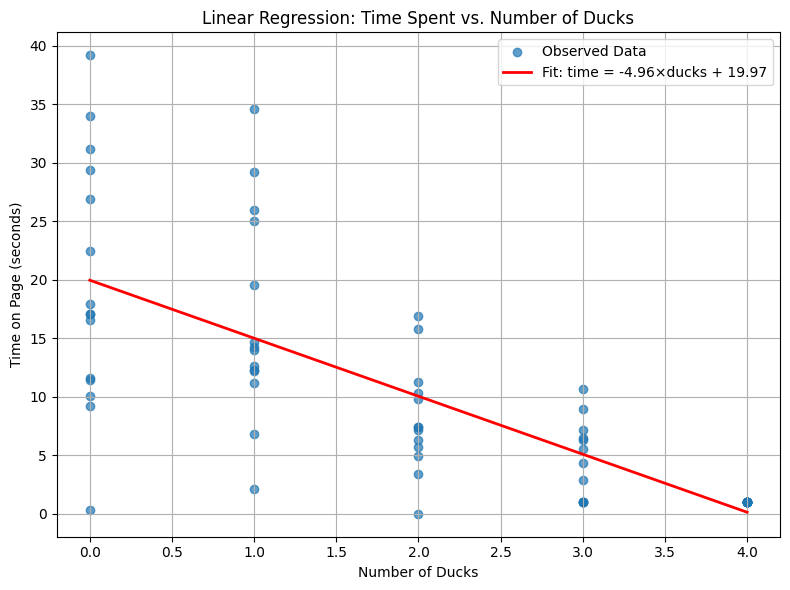

Intercept: 19.97
Slope: -4.96


In [38]:
x_vals = np.linspace(0, 4, 100).reshape(-1, 1)
y_pred = model.predict(x_vals)

plt.figure(figsize=(8, 6))

plt.scatter(num_ducks, num_seconds, alpha=0.7, label="Observed Data")
plt.plot(x_vals, y_pred, color="red", linewidth=2,
         label=f"Fit: time = {a2:.2f}×ducks + {b2:.2f}")
plt.xlabel("Number of Ducks")
plt.ylabel("Time on Page (seconds)")
plt.title("Linear Regression: Time Spent vs. Number of Ducks")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")

*(c)* What are your recommendations, based on this result?
    Be sure to give the basis for your recommendation,
    including the type of model and the result.

- The model shows a strong negative relationship because each additional duck is associated with ~5 fewer seconds on the page (slope ≈ −4.96). With 0 ducks, visitors stay ~18 seconds on average, dropping to ~1 second with every 4 ducks.

- Recommendation: do not add the ducks. The downward trend is consistent across all duck counts, providing strong evidence they harm engagement. While correlation is not causation, the effect is large enough to take seriously. Further A/B testing with a larger sample would confirm, but based on this data the ducks should be dropped.

# 3. More mosquitos

My kid's class all went camping,
and came home with mosquito bites.
Thanks to a post-trip poll,
we know how many mosquito bites
each of the 27 kids had.
Here are the numbers:

In [39]:
bites = np.array([4, 5, 4, 2, 4, 8, 4, 6, 7, 5, 4, 0, 5, 7, 5, 3, 2, 0, 3, 4, 5, 3, 6, 1, 2, 3, 5])

Furthermore, a parent has measured the concentration
of some volatile organics in each kids' breath.
Here are the concentrations for the 27 kids (in the same order as `bites`, above),
in units of parts per million (ppm):

In [40]:
odor = np.array([ 2.8,  4.4,  6.9,  2.3,  5.9, 10.2,  3.2,  7.6,  6.3,  4.5,  4.3,
                0. ,  8.2,  5.4,  7.6,  3.3,  3.9,  0.1,  2.7,  4.7,  2.1,  4.3,
               11.3,  1.7,  2.8,  2.9,  8.5])

Our goal is to determine how odor affects the number of bites.
To do this, we'll fit a *Poisson* model:
if $Y_i$ is the number of bites the $i^\text{th}$ kid got,
and $X_i$ is their "odor" value, then we want to fit:
$$\begin{aligned}
    Y_i \sim \text{Poisson}(\text{mean}= \exp(a X_i + b)) ,
\end{aligned}$$
i.e., find the values of $a$ and $b$ at which this model
best fits the data.
To do this:

*Note:* we will cover this sort of model more next week,
but *you already know how to do this* - it's just doing maximum likelihood
to fit a model with two parameters.

*(a)* Write down (in math) the negative log-likelihood function:
    this should take $a$ and $b$ as arguments,
    and return the negative log likelihood of the data (i.e., of `bites` and `odor`)
    under the model above.



For the Poisson model $Y_i \sim \text{Poisson}(\lambda_i)$ with $\lambda_i = \exp(aX_i + b)$, 
the log-likelihood is:

$$\ell(a, b) = \sum_{i=1}^{n} \left[ Y_i \log(\lambda_i) - \lambda_i - \log(Y_i!) \right]$$

Substituting $\lambda_i = \exp(aX_i + b)$:

$$\ell(a, b) = \sum_{i=1}^{n} \left[ Y_i(aX_i + b) - \exp(aX_i + b) - \log(Y_i!) \right]$$

The negative log-likelihood is:

$$-\ell(a, b) = \sum_{i=1}^{n} \left[ \exp(aX_i + b) - Y_i(aX_i + b) + \log(Y_i!) \right]$$

Note: the $\log(Y_i!)$ term is constant with respect to $a$ and $b$, so it does not affect 
the location of the minimum — but we include it for completeness.

*(b)* Use your function from (a) and `scipy.optimize.minimize` to find
    the maximum likelihood estimates of $a$ and $b$.


In [41]:
def neg_log_likelihood(params):
    a, b = params
    lam = np.exp(a * odor + b)
    return -np.sum(poisson.logpmf(bites, lam))

# Minimize using Nelder-Mead
result = minimize(neg_log_likelihood, x0=[0.1, 1.0], method='Nelder-Mead')
a_hat, b_hat = result.x

print(f"Estimated a: {a_hat:.4f}")
print(f"Estimated b: {b_hat:.4f}")
print(f"Convergence: {result.message}")

Estimated a: 0.1294
Estimated b: 0.6949
Convergence: Optimization terminated successfully.


*(c)* Showing how expected number of bites (using the MLE values of $a$ and $b$ from (b))
    increases with odor and how this compares to the observed number of bites
    (for instance, by plot of the data with a line for the expected number).

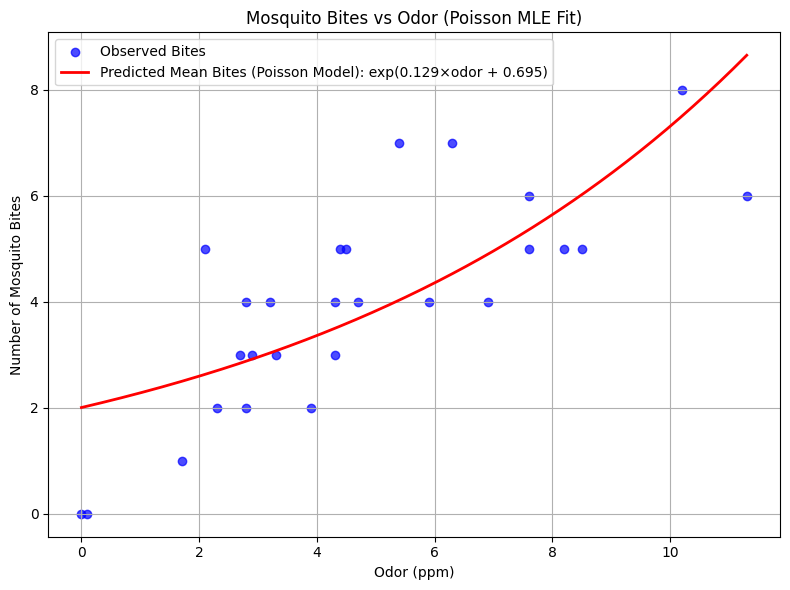

Expected bites at odor=0 ppm:  2.00
Expected bites at odor=10 ppm: 7.31


In [44]:
odor_range = np.linspace(odor.min(), odor.max(), 200)
expected_bites = np.exp(a_hat * odor_range + b_hat)

plt.figure(figsize=(8, 6))
plt.scatter(odor, bites, color='blue', alpha=0.7, label="Observed Bites")
plt.plot(odor_range, expected_bites, color='red', linewidth=2,
         label=f"Predicted Mean Bites (Poisson Model): exp({a_hat:.3f}×odor + {b_hat:.3f})")
plt.xlabel("Odor (ppm)")
plt.ylabel("Number of Mosquito Bites")
plt.title("Mosquito Bites vs Odor (Poisson MLE Fit)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Expected bites at odor=0 ppm:  {np.exp(b_hat):.2f}")
print(f"Expected bites at odor=10 ppm: {np.exp(a_hat*10 + b_hat):.2f}")

The fitted Poisson model confirms a positive relationship between odor concentration and 
mosquito bites. Kids with higher volatile organic concentrations attracted more bites. 
The expected bites increase exponentially with odor: from **2.00 bites at 0 ppm** up to 
**7.31 bites at 10 ppm** (slope $\hat{a} = 0.129$, intercept $\hat{b} = 0.695$). 
The curve fits the data reasonably well, capturing the upward trend across the range of odor values.